In [1]:
import pandas as pd

df = pd.read_csv("full_dataset.csv")
print(df.head())
print(df.columns)

   Student_ID  Age  Gender  Degree Branch  CGPA  Internships  Projects  \
0        1048   22  Female  B.Tech    ECE  6.29            0         3   
1       37820   20  Female     BCA    ECE  6.05            1         4   
2       49668   22    Male     MCA     ME  7.22            1         4   
3       19467   22    Male     MCA     ME  7.78            2         4   
4       23094   20  Female  B.Tech     ME  7.63            1         4   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   
1              6                     8                   59   
2              6                     6                   58   
3              6                     6                   90   
4              6                     5                   79   

   Soft_Skills_Rating  Certifications  Backlogs Placement_Status  
0                   5               1         3       Not Placed  
1                   8               2     

### Feature Selection

Based on previous analysis, the following features were selected for clustering:

- CGPA
- Internships
- Projects
- Certifications

These variables were identified as the most relevant predictors of placement outcomes.

In [2]:
features = df[["CGPA", "Internships", "Projects", "Certifications"]]

### Data Standardization

The selected features were standardized to ensure that all variables contribute equally to the clustering process.

In [3]:
from sklearn.preprocessing import StandardScaler

# Handle missing values
features = features.dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### Hierarchical Clustering Model

Hierarchical clustering was performed using Ward’s linkage method, which minimizes the variance within clusters.

In [4]:
from scipy.cluster.hierarchy import linkage

linked = linkage(X_scaled, method='ward')

### Dendrogram

A dendrogram was used to visualize the hierarchical clustering process and determine the optimal number of clusters.

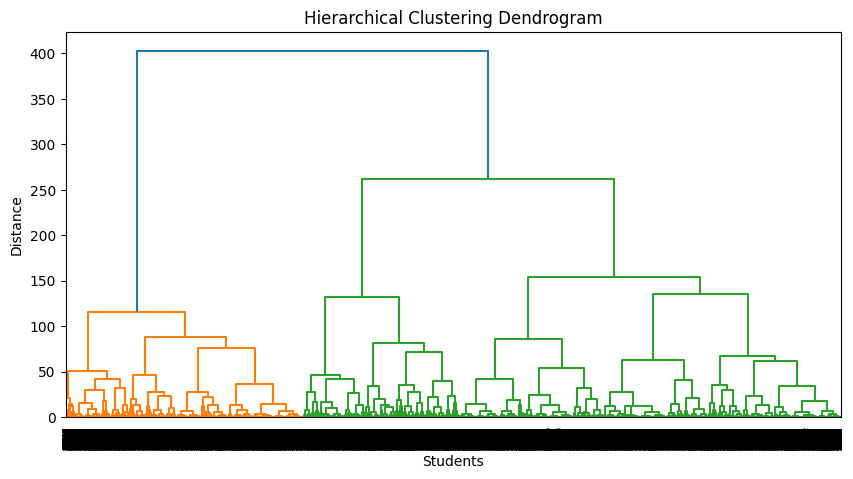

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

### Determining the Number of Clusters

Based on the dendrogram, a clear separation between clusters is observed. The optimal number of clusters was chosen as **K = 3**, where the distance between merged clusters shows a significant increase.

In [6]:
from scipy.cluster.hierarchy import fcluster

k = 3  # change to 4 if needed
df["cluster_hier"] = fcluster(linked, k, criterion='maxclust')

### Cluster Analysis

The clusters were analyzed by examining the average values of each feature within each group.

In [7]:
cluster_summary = df.groupby("cluster_hier")[["CGPA", "Internships", "Projects", "Certifications"]].mean()
print(cluster_summary)

                  CGPA  Internships  Projects  Certifications
cluster_hier                                                 
1             6.293472     0.271673  2.748208        0.962130
2             7.970801     1.836358  4.883686        2.601825
3             7.052172     0.656472  3.885599        2.000000


### Validation Using Placement Status

To evaluate the effectiveness of the clustering, the distribution of placement outcomes was analyzed within each cluster.

In [10]:
placement_summary = df.groupby("cluster_hier")["Placement_Status"].value_counts(normalize=True)
print(placement_summary)

cluster_hier  Placement_Status
1             Not Placed          0.982858
              Placed              0.017142
2             Placed              0.670410
              Not Placed          0.329590
3             Not Placed          0.547296
              Placed              0.452704
Name: proportion, dtype: float64


### Results and Interpretation

The hierarchical clustering model identified three distinct groups of students:

- **Cluster 1:** High-performing students with strong CGPA and multiple internships/projects. This group shows the highest placement rates.
- **Cluster 2:** Moderately performing students with average experience levels. This group shows mixed placement outcomes.
- **Cluster 3:** Students with lower academic performance and fewer experiences, associated with lower placement rates.

These results indicate that academic performance and practical experience play a significant role in determining placement success.